<a href="https://colab.research.google.com/github/JelenaMaxVicovac/ml_final_task/blob/main/notebook/Jelena_Maksimovic_Vicovac_final_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Loading and inspecting the dataset

- loading csv file from GitHub
- checking number of rows and columns
- displaying the first few rows
- review data types and basic information

In [5]:
import pandas as pd

# load dataset from github
url="https://raw.githubusercontent.com/JelenaMaxVicovac/ml_final_task/main/data/IMLP4_TASK_03-products.csv"
df=pd.read_csv (url)

# data shape
print ("rows,columns:",df.shape)

# First five rows
print ("\nFirst five rows:")
print (df.head())

# Dataset info
print ("Dataset info:")
df.info()

rows,columns: (35311, 8)

First five rows:
   product ID                                      Product Title  Merchant ID  \
0           1                    apple iphone 8 plus 64gb silver            1   
1           2                apple iphone 8 plus 64 gb spacegrau            2   
2           3  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...            3   
3           4                apple iphone 8 plus 64gb space grey            4   
4           5  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...            5   

   Category Label _Product Code  Number_of_Views  Merchant Rating  \
0   Mobile Phones    QA-2276-XC            860.0              2.5   
1   Mobile Phones    KA-2501-QO           3772.0              4.8   
2   Mobile Phones    FP-8086-IE           3092.0              3.9   
3   Mobile Phones    YI-0086-US            466.0              3.4   
4   Mobile Phones    NZ-3586-WP           4426.0              1.6   

   Listing Date    
0       5/10/2024  
1      12/31/20

# Step 2: EDA

## Checking missing values

Missing values per column:
product ID           0
Product Title      172
Merchant ID          0
 Category Label     44
_Product Code       95
Number_of_Views     14
Merchant Rating    170
 Listing Date       59
dtype: int64


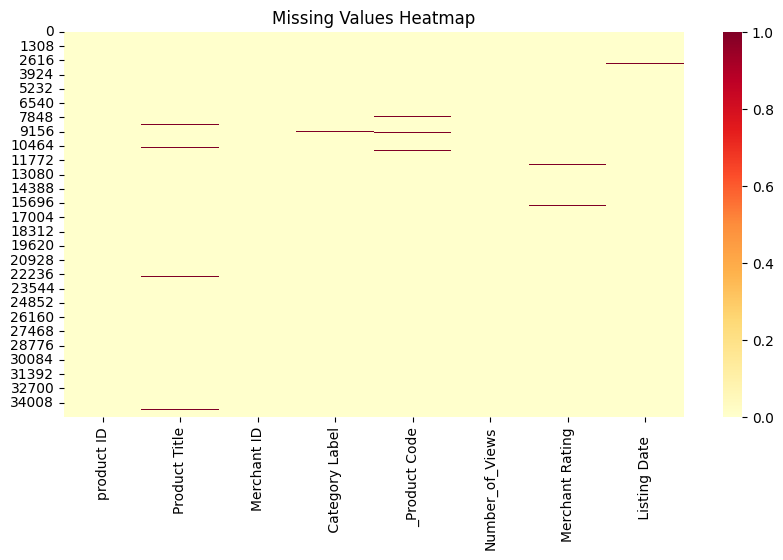

In [6]:
# Count missing values per column
print ("Missing values per column:")
print (df.isna().sum())

# Visualize missing data
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cmap="YlOrRd")
plt.title("Missing Values Heatmap")
plt.show()

The highest number of missing values is in the Product title and Merchant Rating columns.

## Checking column Category Label

In [7]:

# printing names of each column
print (df.columns)

# cleaning column names
df.columns = df.columns.str.strip()

# Count occurrences of each category label
category_counts = df['Category Label'].value_counts()

# Print counts
print("Category distribution (counts):")
print(category_counts)



Index(['product ID', 'Product Title', 'Merchant ID', ' Category Label',
       '_Product Code', 'Number_of_Views', 'Merchant Rating',
       ' Listing Date  '],
      dtype='object')
Category distribution (counts):
Category Label
Fridge Freezers     5495
Washing Machines    4036
Mobile Phones       4020
CPUs                3771
TVs                 3564
Fridges             3457
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
fridge               123
CPU                   84
Mobile Phone          55
Name: count, dtype: int64


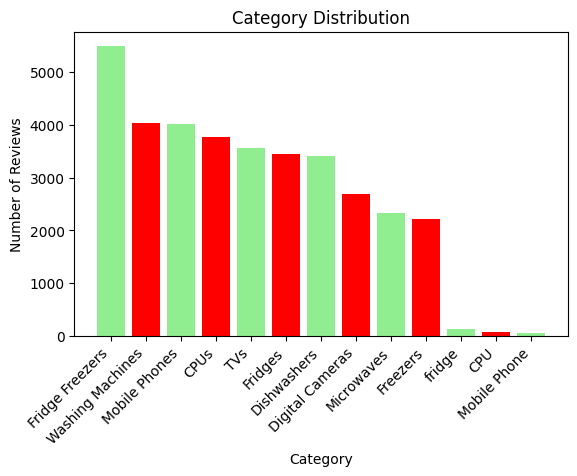

In [8]:
# Plot category distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(category_counts.index, category_counts.values, color=['lightgreen', 'red'])
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

## Checking column Product Title

In [9]:
# Data type of the 'Product Title' column
print("Data type of Product Title column:", df['Product Title'].dtype)

# First 10 values from the column
print("\nFirst 10 values in Product Title column:")
print(df['Product Title'].head(10))

# 20 most frequent values in the column
print("\nTop 20 most frequent values in Product Title column:")
print(df['Product Title'].value_counts().head(20))

# Check for known non-numeric text values
problematic_values = ['Not Available', 'N/A', 'None', '-', 'unknown', 'Unavailable']

# Identify rows with problematic values
mask_problematic = df['Product Title'].astype(str).str.strip().isin(problematic_values)
df_problematic = df[mask_problematic]
print(f"\nFound {len(df_problematic)} rows with problematic textual values:")
display(df_problematic[['Product Title']].drop_duplicates())

# identify wich values are not string
df['Product Title'].apply(type).value_counts()
mask = df['Product Title'].apply(lambda x: not isinstance(x, str))
df_non_strings = df[mask]
print("Number of values wich are not string:",len(df_non_strings))
print (df_non_strings)

# Checking how many rows contain only empty strings or spaces
print ("Rows with empty strings or spaces only")
df['Product Title'].str.strip().eq('').sum()

Data type of Product Title column: object

First 10 values in Product Title column:
0                      apple iphone 8 plus 64gb silver
1                  apple iphone 8 plus 64 gb spacegrau
2    apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...
3                  apple iphone 8 plus 64gb space grey
4    apple iphone 8 plus gold 5.5 64gb 4g unlocked ...
5    apple iphone 8 plus gold 5.5 64gb 4g unlocked ...
6                 apple iphone 8 plus 64 gb space grey
7                  apple iphone 8 plus 64gb space grey
8                  apple iphone 8 plus 64gb space grey
9                  apple iphone 8 plus 64gb space grey
Name: Product Title, dtype: object

Top 20 most frequent values in Product Title column:
Product Title
washing machine                                                           90
built in fully integrated dishwasher                                      35
frost free fridge freezer                                                 34
washer dryer                    

,Product Title


Number of values wich are not string: 172
       product ID Product Title  Merchant ID Category Label _Product Code  \
172           173           NaN            1  Mobile Phones    GZ-3098-QU   
443           444           NaN           15  Mobile Phones    BE-1771-PE   
548           549           NaN            8  Mobile Phones    EH-6626-EA   
553           554           NaN            3  Mobile Phones    TA-4759-MR   
599           600           NaN           24  Mobile Phones    ND-9919-XI   
...           ...           ...          ...            ...           ...   
34429       46442           NaN          297        Fridges    TT-6246-EB   
34615       46636           NaN          298        Fridges    HU-2729-JQ   
34632       46653           NaN          297        Fridges    RB-0968-ZY   
34920       46948           NaN          119        Fridges    FV-2962-JM   
34985       47013           NaN          119        Fridges    NR-8035-HN   

       Number_of_Views  Merchant 

np.int64(0)

There are 172 float values, and 172 values wich are not string. Conclusion - All 172 problematic values are NaN. There are not values wich contain only empty strings or spaces

# Step 3: Cleaning and stardadization of Data Frame columns

## Standardization of column names

In [10]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.strip('_')

df.columns

Index(['product_id', 'product_title', 'merchant_id', 'category_label',
       'product_code', 'number_of_views', 'merchant_rating', 'listing_date'],
      dtype='object')

## Cleaning missing values

In [11]:
# drop all rows with missing values
df=df.dropna()

# new data shape
print ("New dataset shape:", df.shape)

# missing values per column
print (df.isna().sum())

New dataset shape: (34760, 8)
product_id         0
product_title      0
merchant_id        0
category_label     0
product_code       0
number_of_views    0
merchant_rating    0
listing_date       0
dtype: int64


## Standardization of column Category Label

In [12]:
# Convert all values to lowercase and strip extra spaces
df['category_label'] = df['category_label'].astype(str).str.lower().str.strip()

# standardization Category Label
mapping = {
    'fridge freezers': 'fridge',
    'fridges': 'fridge',
    'freezers': 'fridge',
    'mobile phones':'mobile phone',
    'cpus':'cpu'
}
df['category_label'] = df['category_label'].replace(mapping)


# Convert column type to 'category'
df['category_label'] = df['category_label'].astype('category')

df['category_label'].unique()




['mobile phone', 'tvs', 'cpu', 'digital cameras', 'microwaves', 'dishwashers', 'washing machines', 'fridge']
Categories (8, object): ['cpu', 'digital cameras', 'dishwashers', 'fridge', 'microwaves',
                         'mobile phone', 'tvs', 'washing machines']

# Step 4. Feature Engineering

## Removing irrelenavt columns
We will remove columns that are not usefull for model training


In [13]:
df=df.drop(columns=['product_id','merchant_id','product_code','number_of_views','merchant_rating','listing_date'])
df.columns

Index(['product_title', 'category_label'], dtype='object')

## Now, we will add new columns that can be usefull for model training

count    34760.000000
mean        52.972066
std         22.417916
min          5.000000
25%         39.000000
50%         52.000000
75%         65.000000
max        200.000000
Name: product_title_length, dtype: float64
product_title_length statistics by category:
                    count       mean        std   min   25%   50%   75%    max
category_label                                                                
cpu                3792.0  67.016350  20.259078  11.0  55.0  65.0  76.0  190.0
digital cameras    2661.0  50.118001  24.512564   6.0  34.0  44.0  61.0  180.0
dishwashers        3374.0  50.184351  17.939197  10.0  39.0  51.0  61.0  192.0
fridge            11130.0  51.836658  19.654114   8.0  39.0  50.0  65.0  173.0
microwaves         2307.0  51.788903  18.850512  11.0  39.0  52.0  65.0  164.0
mobile phone       4023.0  46.155108  30.651590   5.0  26.0  40.0  57.0  200.0
tvs                3502.0  54.741576  23.339558   6.0  40.0  53.0  65.0  195.0
washing machines   3971.0

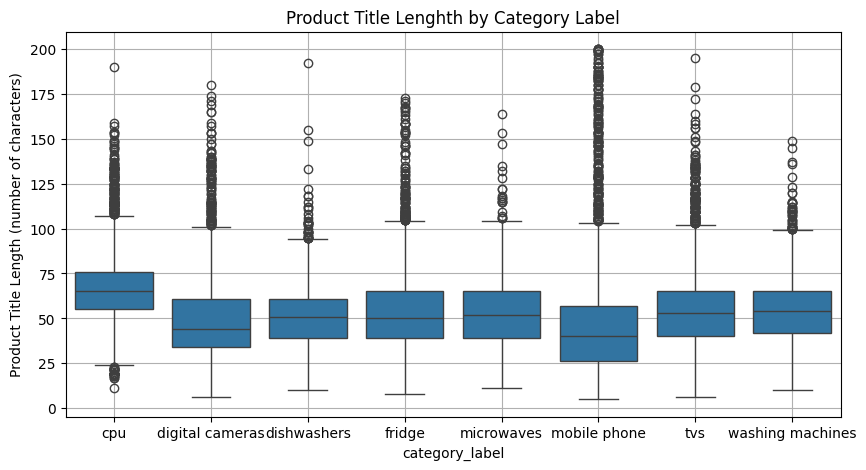

In [14]:
df['product_title_length'] = df['product_title'].str.len()

# basic stats
print(df['product_title_length'].describe())

# Group by category and describe product_title_length
print("product_title_length statistics by category:")
print(df.groupby('category_label', observed=False)['product_title_length'].describe())

# Visualize distribution of product_title_length by category
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='category_label', y='product_title_length')
plt.title("Product Title Lenghth by Category Label")
plt.xlabel("category_label")
plt.ylabel("Product Title Length (number of characters)")
plt.grid(True)
plt.show()


Product title length varies across categories. Technical products such as CPUs and TVs tend to have longer and more variable names, while mobile phones have shorter and more consistent titles.

## Checking if columns have numbers or special caracters in name

count     34760
unique        2
top       False
freq      26911
Name: has_special_chars, dtype: object
product_title_length statistics by category:
                  count unique    top  freq
category_label                             
cpu                3792      2   True  3239
digital cameras    2661      2  False  1948
dishwashers        3374      2  False  3196
fridge            11130      2  False  9693
microwaves         2307      2  False  2126
mobile phone       4023      2  False  3004
tvs                3502      2  False  2856
washing machines   3971      2  False  3535


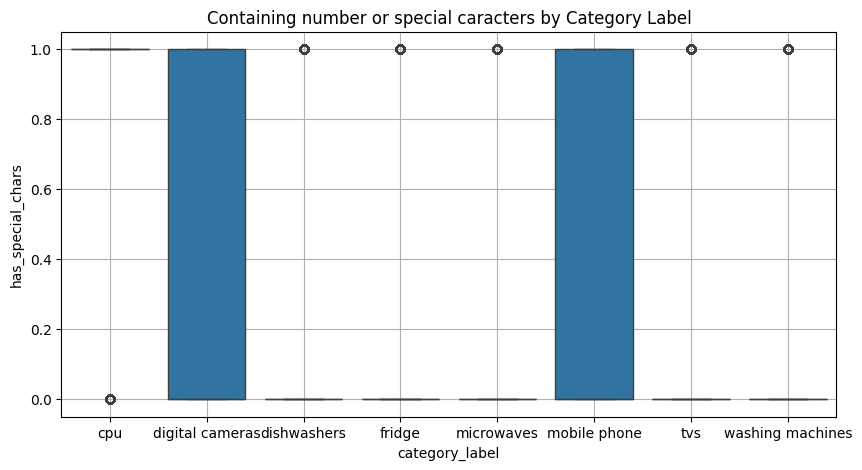

In [15]:

df['has_numbers'] = df['product_title'].str.contains(r'\d', regex=True)
df['has_special_chars'] = df['product_title'].str.contains(r'[^a-zA-Z0-9\s]', regex=True)
df['title_content_check'] = (
    df['has_numbers'].map({True: 'numbers', False: ''}) +
    df['has_special_chars'].map({True: ' special_chars', False: ''})
).str.strip()

# basic stats
print(df['has_special_chars'].describe())

# Group by category and describe has_special_chars
print("product_title_length statistics by category:")
print(df.groupby('category_label', observed=False)['has_special_chars'].describe())

# Visualization
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='category_label', y='has_special_chars')
plt.title("Containing number or special caracters by Category Label")
plt.xlabel("category_label")
plt.ylabel("has_special_chars")
plt.grid(True)
plt.show()



The chart clearly indicates that more technically complex devices (CPUs, mobile phones, cameras) are much more likely to include symbols and numbers in their model names. In contrast, household appliances (washing machines, fridges) in your dataset are primarily named using plain text.

count     34760
unique        1
top       False
freq      34760
Name: has_uppercase_words, dtype: object
has_uppercase_words statistics by category:
                  count unique    top   freq
category_label                              
cpu                3792      1  False   3792
digital cameras    2661      1  False   2661
dishwashers        3374      1  False   3374
fridge            11130      1  False  11130
microwaves         2307      1  False   2307
mobile phone       4023      1  False   4023
tvs                3502      1  False   3502
washing machines   3971      1  False   3971


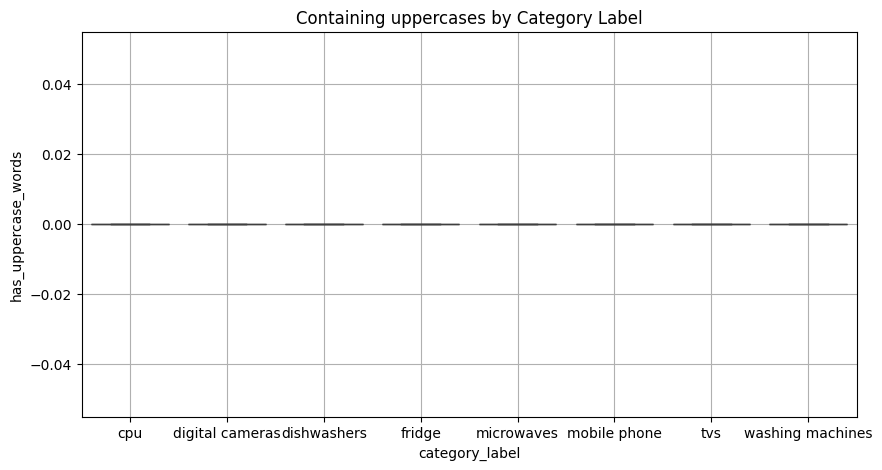

In [16]:
df['has_uppercase_words'] = df['product_title'].str.contains(r'\b[A-Z]{2,}\b', regex=True)

# basic stats
print(df['has_uppercase_words'].describe())

# Group by category and describe has_uppercase_words
print("has_uppercase_words statistics by category:")
print(df.groupby('category_label', observed=False)['has_uppercase_words'].describe())

# Visualization
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='category_label', y='has_uppercase_words')
plt.title("Containing uppercases by Category Label")
plt.xlabel("category_label")
plt.ylabel("has_uppercase_words")
plt.grid(True)
plt.show()


All horizontal lines for every category are positioned at the 0.0 mark. There are no boxes, whiskers, or outliers, meaning this feature has zero variance and should not be included in the machine learning model

Maximum word length per title statistics by category:
                    count       mean       std  min   25%   50%   75%   max
category_label                                                             
cpu                3792.0   9.406909  2.083532  4.0   9.0   9.0  10.0  20.0
digital cameras    2661.0   7.778655  1.976994  3.0   7.0   7.0   9.0  23.0
dishwashers        3374.0  10.991405  2.334517  4.0  10.0  10.0  12.0  33.0
fridge            11130.0  10.185714  2.402471  5.0   9.0  10.0  12.0  33.0
microwaves         2307.0  10.255743  2.065400  4.0   9.0  10.0  11.0  23.0
mobile phone       4023.0   8.009694  2.230425  2.0   6.0   8.0  10.0  31.0
tvs                3502.0  10.131068  2.859703  3.0   8.0  10.0  11.0  25.0
washing machines   3971.0  10.234450  2.601914  6.0   9.0  10.0  12.0  27.0


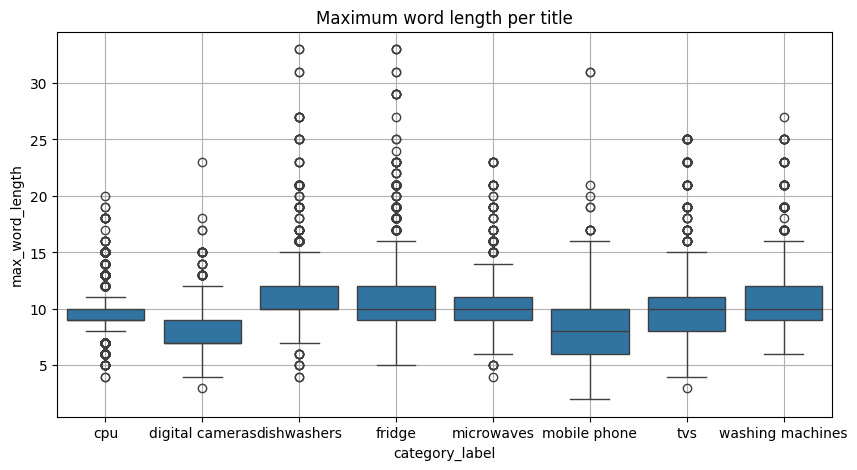

In [17]:
# Maximum word length per title
df['max_word_length'] = df['product_title'].apply(lambda x: max([len(word) for word in str(x).split()]) if x else 0)

# Group by category and describe maximum word length per title
print("Maximum word length per title statistics by category:")
print(df.groupby('category_label', observed=False)['max_word_length'].describe())

# Visualization
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='category_label', y='max_word_length')
plt.title("Maximum word length per title")
plt.xlabel("category_label")
plt.ylabel("max_word_length")
plt.grid(True)
plt.show()


Most categories have a median maximum word length between 8 and 11 characters.

Dishwashers and Washing machines tend to have slightly longer "longest words" on average.

Digital cameras and Mobile phones show a tendency toward shorter "longest words" (indicated by lower medians).

Outliers - there are extreme values within the Dishwashers, Fridge and Mobile phone categories.

The 'Mobile phone' category features the widest interquartile range - this indicates that naming conventions in this category are the most diverse—ranging from very short words to extremely long technical codes.

The 'CPU' category has a very compressed boxplot, suggesting that processor names are highly uniform and standardized within the dataset (with most maximum word lengths clustered around 9–10 characters.

In [18]:
df.columns
df.head()


,product_title,category_label,product_title_length,has_numbers,has_special_chars,title_content_check,has_uppercase_words,max_word_length
0,apple iphone 8 plus 64gb silver,mobile phone,31,True,False,numbers,False,6
1,apple iphone 8 plus 64 gb spacegrau,mobile phone,35,True,False,numbers,False,9
2,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,mobile phone,70,True,True,numbers special_chars,False,10
3,apple iphone 8 plus 64gb space grey,mobile phone,35,True,False,numbers,False,6
4,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,mobile phone,54,True,True,numbers special_chars,False,8


# Step 5: Training and Comparing Multiple Machine Learning Models



## Split dataset into training and test sets

In [19]:
from sklearn.model_selection import train_test_split

# Features and label
X = df[["product_title", "product_title_length", "title_content_check","max_word_length"]]
y = df["category_label"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## Convert columns into numerical vectors

In [20]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer


# Preprocessor: TF-IDF for text, MinMaxScaler for numeric feature
preprocessor = ColumnTransformer(
    transformers=[
        ("title", TfidfVectorizer(), "product_title"),
        ("content", TfidfVectorizer(), "title_content_check"),
        ("length", MinMaxScaler(), ["product_title_length"]),
        ("max_length", MinMaxScaler(), ["max_word_length"])
    ]
)


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline


# List of classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": LinearSVC()
}

# Train and evaluate
for name, model in models.items():
    print(f"\n {name}")
    pipeline=Pipeline([
        ("preprocessing", preprocessor),
        ("classifier",model)
    ])
    pipeline.fit(X_train,y_train)
    y_pred=pipeline.predict(X_test)
    print (classification_report (y_test,y_pred))



 Logistic Regression
                  precision    recall  f1-score   support

             cpu       1.00      1.00      1.00       759
 digital cameras       1.00      0.99      1.00       532
     dishwashers       0.97      0.92      0.95       675
          fridge       0.95      0.99      0.97      2226
      microwaves       1.00      0.94      0.97       461
    mobile phone       0.98      0.99      0.99       805
             tvs       0.98      0.98      0.98       700
washing machines       0.98      0.94      0.96       794

        accuracy                           0.97      6952
       macro avg       0.98      0.97      0.98      6952
    weighted avg       0.98      0.97      0.97      6952


 Naive Bayes
                  precision    recall  f1-score   support

             cpu       0.99      1.00      0.99       759
 digital cameras       1.00      0.99      1.00       532
     dishwashers       1.00      0.86      0.92       675
          fridge       0.90     

**All models show strong performance indicators. The SVM and Random Forest models achieve the highest accuracy, while Naive Bayes has the lowest. Since the SVM model has a slightly better F1 score than Random Forest, I will select SVM as the best model.**